In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

NOTEBOOK_DIR = Path.cwd()
DATA_PATH = NOTEBOOK_DIR / 'PanelResults' / 'dd.dta'

FIGURE_DIR = NOTEBOOK_DIR / 'SI_Figures'
FIGURE_PATH = FIGURE_DIR / 'FigS4.tiff'

POLICIES = {
    'Harbin': {'Xdq1': 0, 'policy_start': pd.Timestamp('2024-11-26')},
    'Shanghai': {'Xdq1': 1, 'policy_start': pd.Timestamp('2025-05-03')},
}
OUTCOMES = {'y11': 'Workload', 'y12': 'Overload ratio (pp)'}
EVENT_TIMES = [-4, -3, -2, 0, 1, 2, 3]
REFERENCE_WEEK = -1
CONTROLS = ['Xcli1', 'Xcli2', 'Xtime1', 'Xtime2', 'Xtime3']
DUMMY_ORDER = ['D_m4', 'D_m3', 'D_m2', 'D_0', 'D_1', 'D_2', 'D_3']

In [2]:
df = pd.read_stata(DATA_PATH)
df['date'] = pd.to_datetime(df['date'])

required = ['alpha', 'date', 'Xdq1', *CONTROLS, *OUTCOMES.keys()]
missing = [column for column in required if column not in df.columns]
if missing:
    raise KeyError(f'Missing required columns in {DATA_PATH}: {missing}')

In [3]:
def dummy_name(event_time):
    if event_time < 0:
        return f'D_m{abs(event_time)}'
    return f'D_{event_time}'

def build_weekly_event_panel(data, city, spec):
    policy_start = spec['policy_start']
    start_sample = policy_start - pd.Timedelta(days=28)
    end_sample = policy_start + pd.Timedelta(days=27)
    sample = data.loc[
        data['Xdq1'].eq(spec['Xdq1']) & data['date'].between(start_sample, end_sample)
    ].copy()
    sample['city'] = city
    sample['policy_start'] = policy_start
    sample['event_time'] = np.floor((sample['date'] - policy_start).dt.days / 7).astype(int)

    expected_times = set(range(-4, 4))
    observed_times = set(sample['event_time'].dropna().unique())
    if not observed_times.issubset(expected_times):
        raise ValueError(f'{city} has event_time values outside [-4, 3]: {sorted(observed_times)}')

    for event_time in EVENT_TIMES:
        sample[dummy_name(event_time)] = sample['event_time'].eq(event_time).astype(int)
    return sample

event_panel = pd.concat(
    [build_weekly_event_panel(df, city, spec) for city, spec in POLICIES.items()],
    ignore_index=True,
)

event_counts = (
    event_panel.groupby(['city', 'event_time'])
    .size()
    .rename('observations')
    .reset_index()
)
event_counts

,city,event_time,observations
0,Harbin,-4,60
1,Harbin,-3,214
2,Harbin,-2,208
3,Harbin,-1,221
4,Harbin,0,233
5,Harbin,1,240
6,Harbin,2,247
7,Harbin,3,250
8,Shanghai,-4,617
9,Shanghai,-3,613


In [4]:
def run_weekly_event_study(sample, outcome):
    formula = f"{outcome} ~ {' + '.join(DUMMY_ORDER + CONTROLS)}"
    result = smf.ols(formula, data=sample).fit(
        cov_type='cluster', cov_kwds={'groups': sample['alpha']}
    )

    records = []
    for event_time in EVENT_TIMES:
        name = dummy_name(event_time)
        estimate = result.params[name]
        std_error = result.bse[name]
        records.append({
            'city': sample['city'].iloc[0],
            'outcome': outcome,
            'event_time': event_time,
            'term': name,
            'estimate': estimate,
            'std_error': std_error,
            'ci_low': estimate - 1.96 * std_error,
            'ci_high': estimate + 1.96 * std_error,
            'nobs': int(result.nobs),
            'adj_r2': result.rsquared_adj,
        })

    f_test = result.f_test('D_m4 = 0, D_m3 = 0, D_m2 = 0')
    test_record = {
        'city': sample['city'].iloc[0],
        'outcome': outcome,
        'lead_window': '-4 to -2',
        'reference_week': REFERENCE_WEEK,
        'f_stat': float(f_test.fvalue),
        'p_value': float(f_test.pvalue),
        'df_num': int(f_test.df_num),
        'df_denom': float(f_test.df_denom),
        'nobs': int(result.nobs),
    }
    return result, pd.DataFrame(records), test_record

models = {}
coef_frames = []
test_records = []

for city in POLICIES:
    city_sample = event_panel.loc[event_panel['city'].eq(city)].copy()
    for outcome in OUTCOMES:
        model_result, coef_frame, test_record = run_weekly_event_study(city_sample, outcome)
        models[(city, outcome)] = model_result
        coef_frames.append(coef_frame)
        test_records.append(test_record)

coef_df = pd.concat(coef_frames, ignore_index=True)
test_df = pd.DataFrame(test_records)



test_df

,city,outcome,lead_window,reference_week,f_stat,p_value,df_num,df_denom,nobs
0,Harbin,y11,-4 to -2,-1,1.482990,0.231596,3,46.0,1673
1,Harbin,y12,-4 to -2,-1,0.395390,0.756911,3,46.0,1673
2,Shanghai,y11,-4 to -2,-1,6.934327,0.000230,3,129.0,4611
3,Shanghai,y12,-4 to -2,-1,2.680603,0.049635,3,129.0,4611


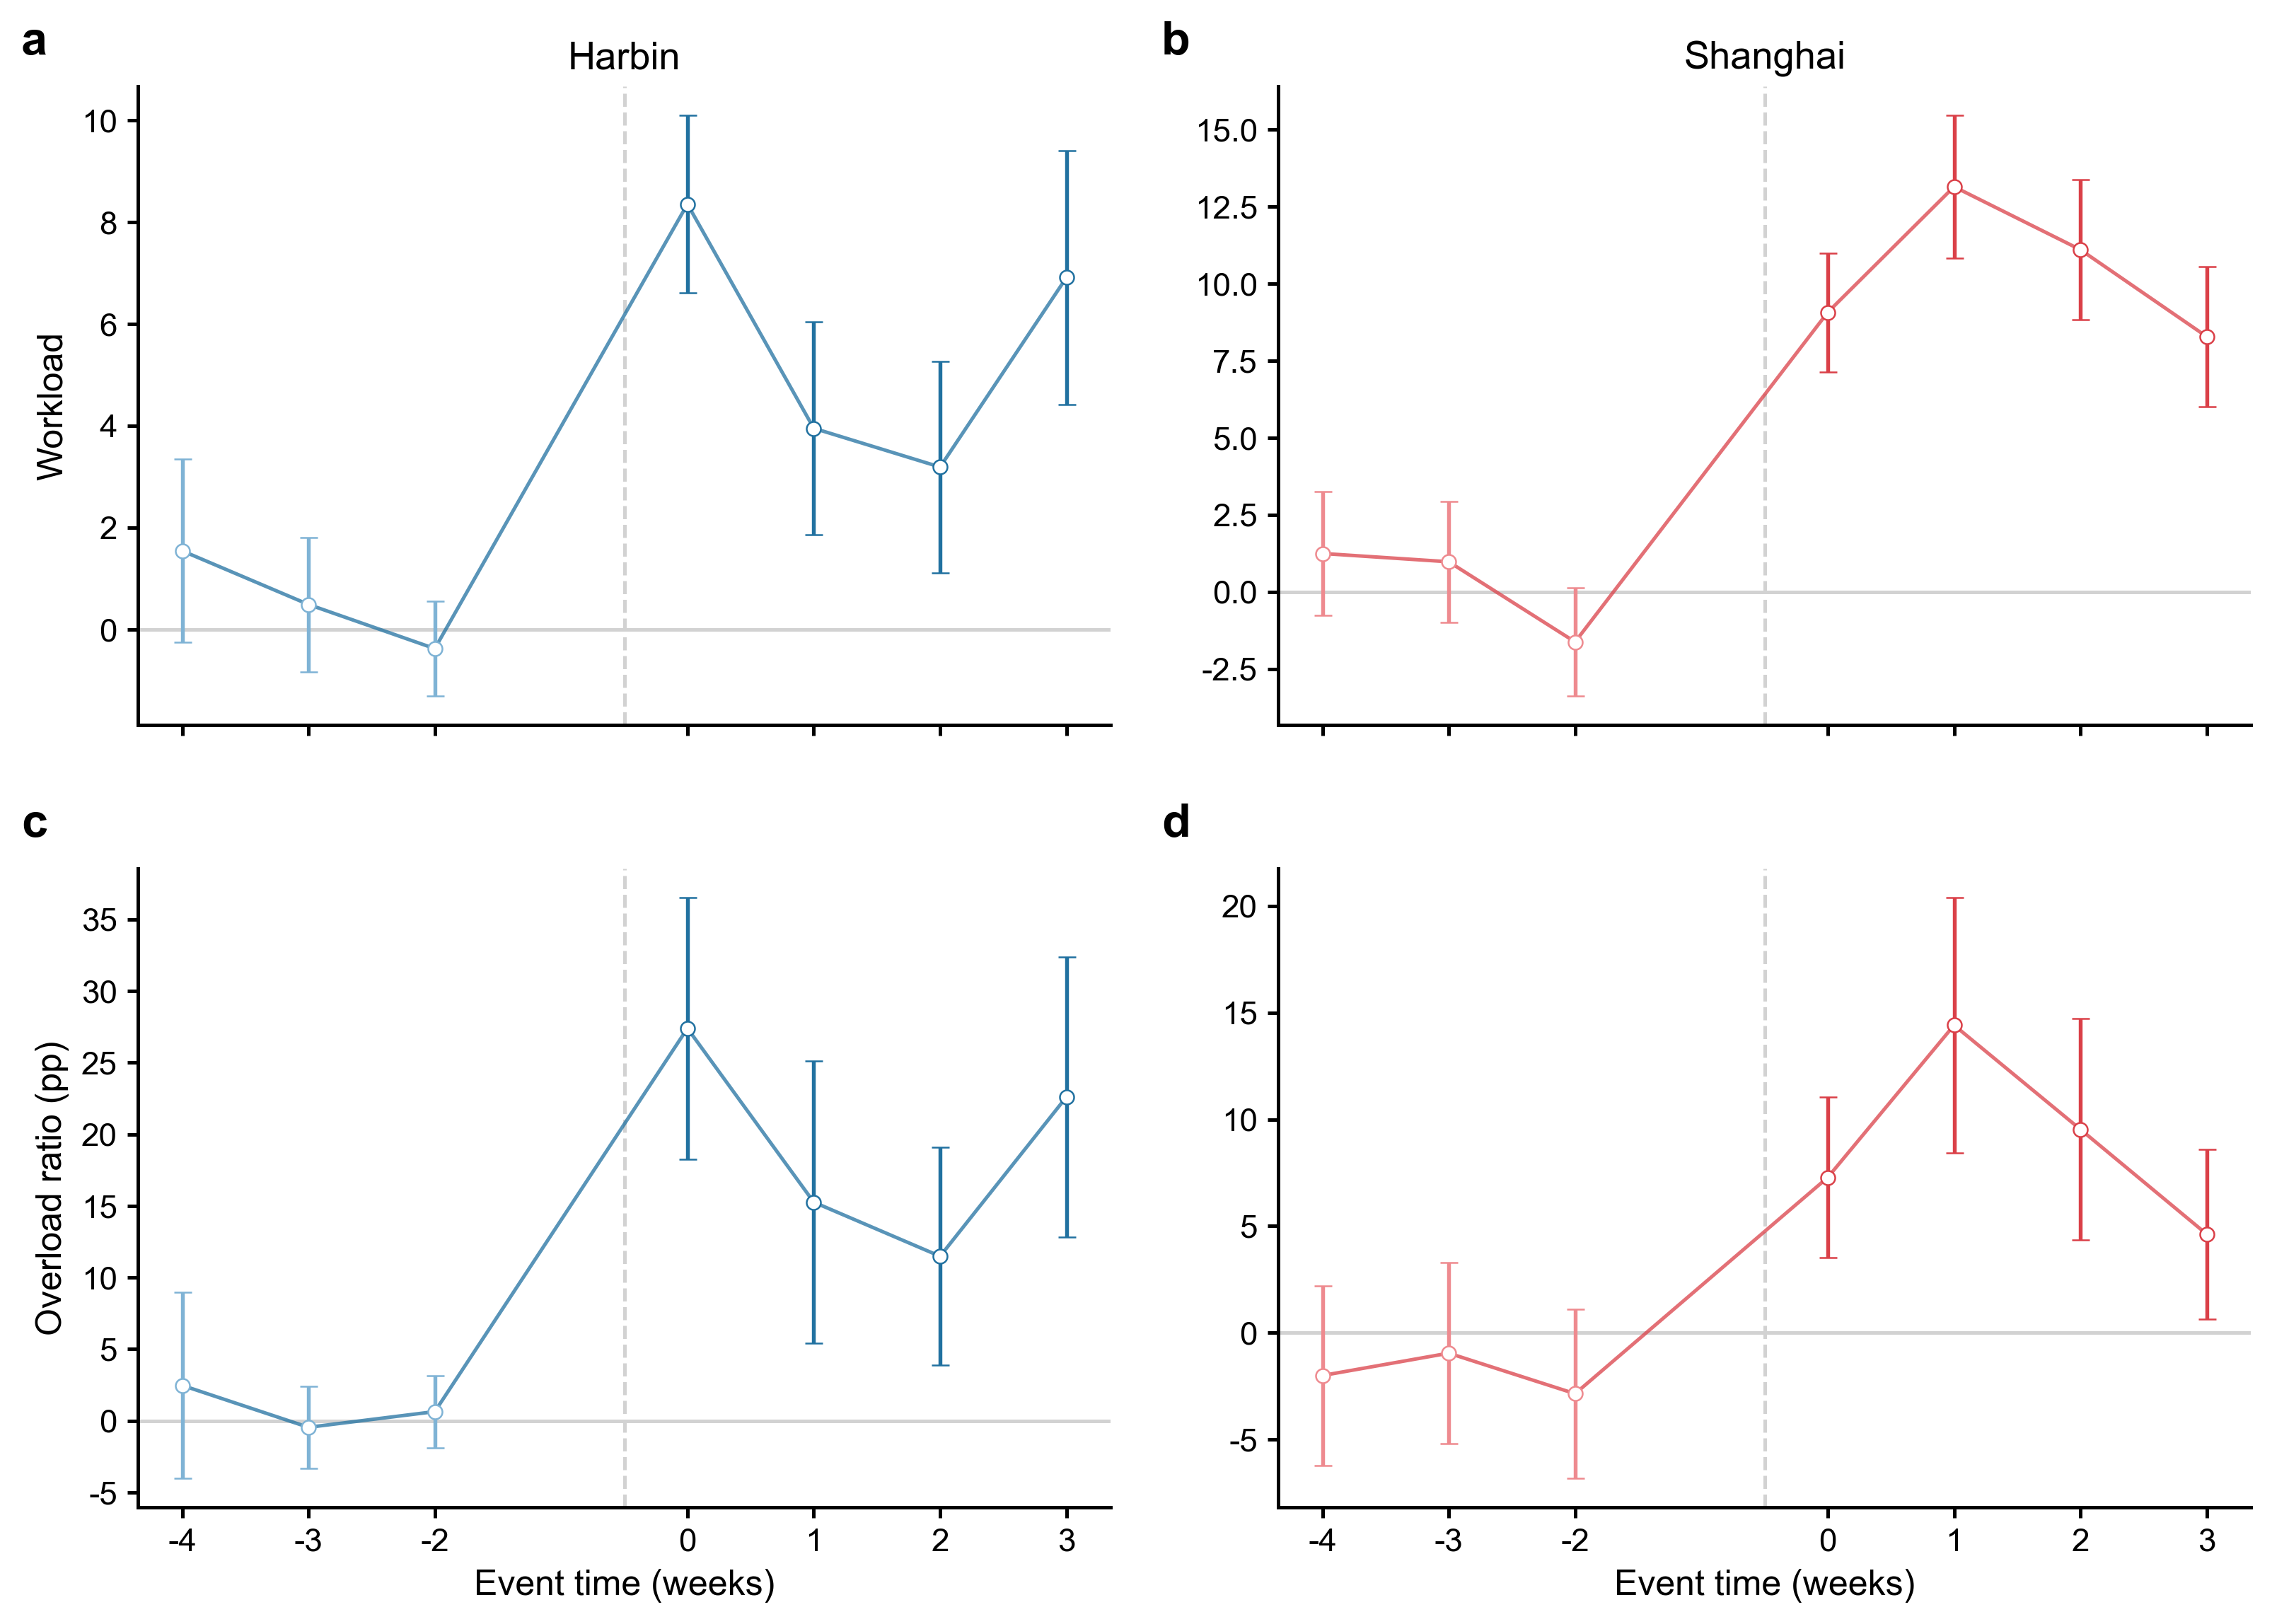

In [5]:
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 12,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 10,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.linewidth': 1.2,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'xtick.major.width': 1.2,
    'ytick.major.width': 1.2,
    'axes.unicode_minus': False,
})

COLORS = {
    'Harbin': {'pre': '#7FB3D5', 'post': '#2171A0'},
    'Shanghai': {'pre': '#EE8A8F', 'post': '#DA4048'},
}
PANEL_LABELS = {
    ('y11', 'Harbin'): 'a',
    ('y11', 'Shanghai'): 'b',
    ('y12', 'Harbin'): 'c',
    ('y12', 'Shanghai'): 'd',
}

fig, axes = plt.subplots(2, 2, figsize=(10.8, 7.8), dpi=300, sharex=True)

for row, (outcome, ylabel) in enumerate(OUTCOMES.items()):
    for col, city in enumerate(POLICIES):
        ax = axes[row, col]
        plot_df = coef_df.loc[
            coef_df['outcome'].eq(outcome) & coef_df['city'].eq(city)
        ].sort_values('event_time')
        pre_df = plot_df.loc[plot_df['event_time'].lt(0)]
        post_df = plot_df.loc[plot_df['event_time'].ge(0)]

        ax.axhline(0, color='#D2D2D2', lw=1.2, zorder=0)
        ax.axvline(-0.5, color='#D2D2D2', lw=1.2, ls='--', zorder=0)

        ax.plot(plot_df['event_time'], plot_df['estimate'], color=COLORS[city]['post'], lw=1.2, alpha=0.75, zorder=1)

        for group_df, color_key in [(pre_df, 'pre'), (post_df, 'post')]:
            color = COLORS[city][color_key]
            ax.errorbar(
                group_df['event_time'],
                group_df['estimate'],
                yerr=[group_df['estimate'] - group_df['ci_low'], group_df['ci_high'] - group_df['estimate']],
                fmt='o',
                color=color,
                ecolor=color,
                markerfacecolor='white',
                markeredgewidth=0.6,
                elinewidth=1.3,
                capsize=3,
                markersize=4.8,
                zorder=3,
            )

        ax.set_title(city if row == 0 else '')
        ax.set_xticks([-4, -3, -2, 0, 1, 2, 3])
        ax.set_xlabel('Event time (weeks)' if row == 1 else '')
        ax.set_ylabel(ylabel if col == 0 else '')
        ax.text(-0.12, 1.05, PANEL_LABELS[(outcome, city)], transform=ax.transAxes, fontsize=16, fontweight='bold')

fig.tight_layout(w_pad=2.0, h_pad=2.0)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(FIGURE_PATH, format='tiff', dpi=600, bbox_inches='tight')
plt.show()
